# Bike Sharing Demand - Regression Project
Predicting hourly bike rental count (target: `cnt`) based on weather and time data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

%matplotlib inline

## 1. Load Data

In [2]:
df = pd.read_csv(r"D:\NTI Project\hour.csv")
print("Shape:", df.shape)
df.head()

Shape: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.4 MB


In [4]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Missing values:
 instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Duplicates: 0


## 2. Data Cleaning

In [5]:
df = df.drop_duplicates()
df = df.dropna()

# 'instant' is just a row index -> drop it
df = df.drop(columns=["instant"])

print("After cleaning, shape:", df.shape)

After cleaning, shape: (17379, 16)


## 3. Feature Engineering from Date

In [6]:
df["dteday"] = pd.to_datetime(df["dteday"])

df["day_of_month"] = df["dteday"].dt.day
df["is_weekend"] = df["weekday"].isin([0, 6]).astype(int)

# We no longer need the raw date once features are extracted
df = df.drop(columns=["dteday"])

# 'casual' + 'registered' sum to 'cnt' (target) -> drop to avoid leakage
df = df.drop(columns=["casual", "registered"])

df.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,day_of_month,is_weekend
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16,1,1
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40,1,1
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32,1,1
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13,1,1
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1,1,1


## 4. Exploratory Data Analysis (EDA)

In [7]:
df.describe()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,day_of_month,is_weekend
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,189.463088,15.683411,0.288509
std,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,181.387599,8.789373,0.453082
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,40.000000,8.000000,0.000000
50%,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,142.000000,16.000000,0.000000
75%,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,281.000000,23.000000,1.000000
max,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,977.000000,31.000000,1.000000


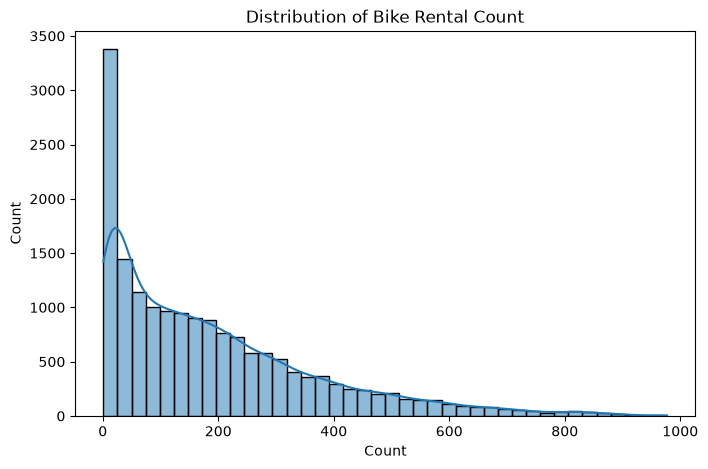

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df["cnt"], kde=True, bins=40)
plt.title("Distribution of Bike Rental Count")
plt.xlabel("Count")
plt.show()

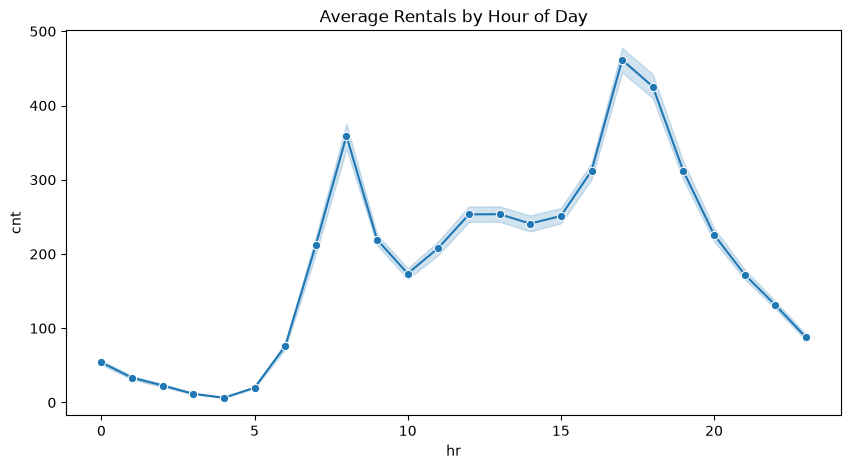

In [9]:
plt.figure(figsize=(10, 5))
sns.lineplot(x="hr", y="cnt", data=df, marker="o")
plt.title("Average Rentals by Hour of Day")
plt.show()

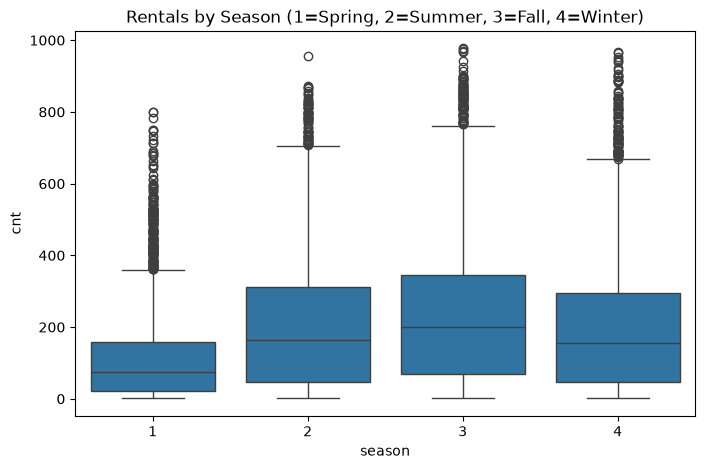

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="season", y="cnt", data=df)
plt.title("Rentals by Season (1=Spring, 2=Summer, 3=Fall, 4=Winter)")
plt.show()

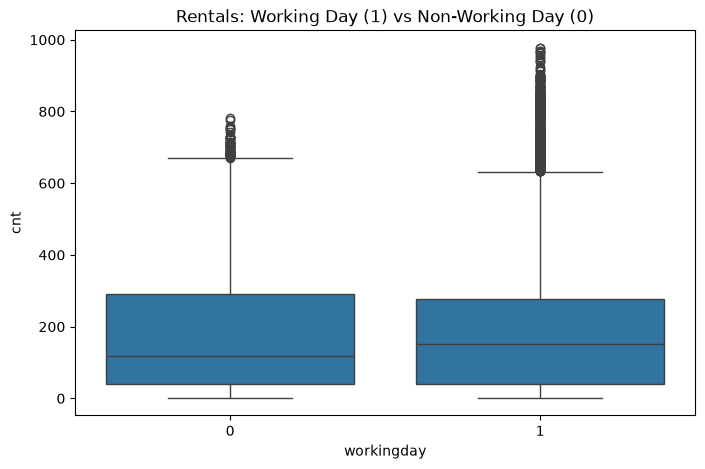

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="workingday", y="cnt", data=df)
plt.title("Rentals: Working Day (1) vs Non-Working Day (0)")
plt.show()

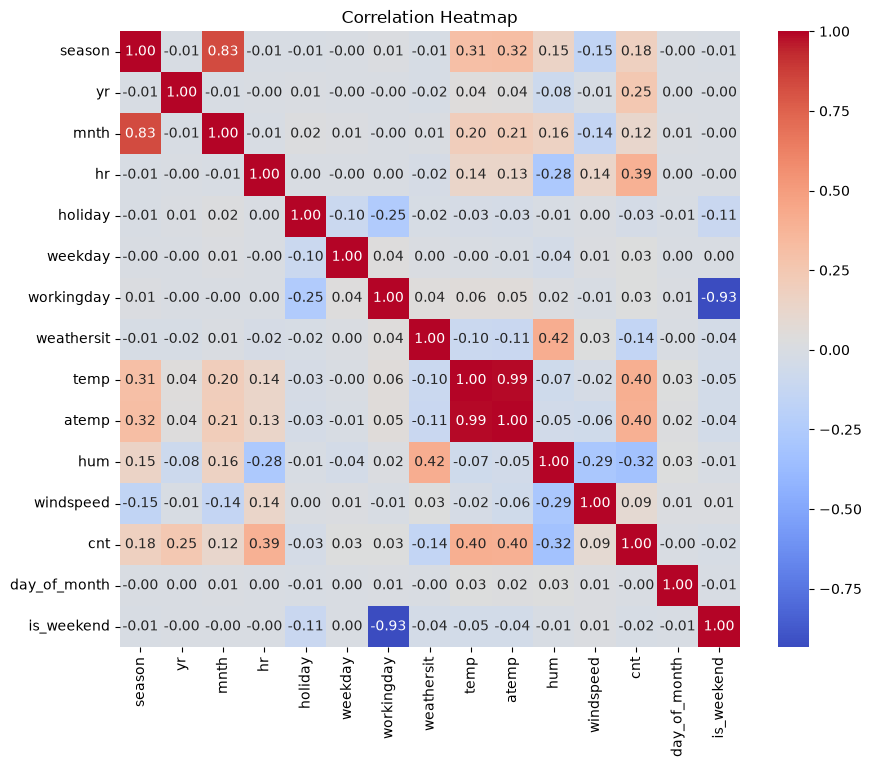

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 5. Train / Test Split

In [13]:
X = df.drop("cnt", axis=1)
y = df["cnt"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (13903, 14)
Test shape: (3476, 14)


## 6. Feature Scaling

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 7. Model 1: Linear Regression

In [15]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

print("R2 Score :", r2_score(y_test, lr_preds))
print("MAE      :", mean_absolute_error(y_test, lr_preds))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, lr_preds)))

R2 Score : 0.3881102222986975
MAE      : 104.79088187855696
RMSE     : 139.19677260441352


## 8. Model 2: Random Forest Regressor

In [16]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)  # RF does not need scaling
rf_preds = rf_model.predict(X_test)

print("R2 Score :", r2_score(y_test, rf_preds))
print("MAE      :", mean_absolute_error(y_test, rf_preds))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, rf_preds)))

R2 Score : 0.9458798095462317
MAE      : 24.48430235903337
RMSE     : 41.39731986887496


## 9. Feature Importance (Random Forest)

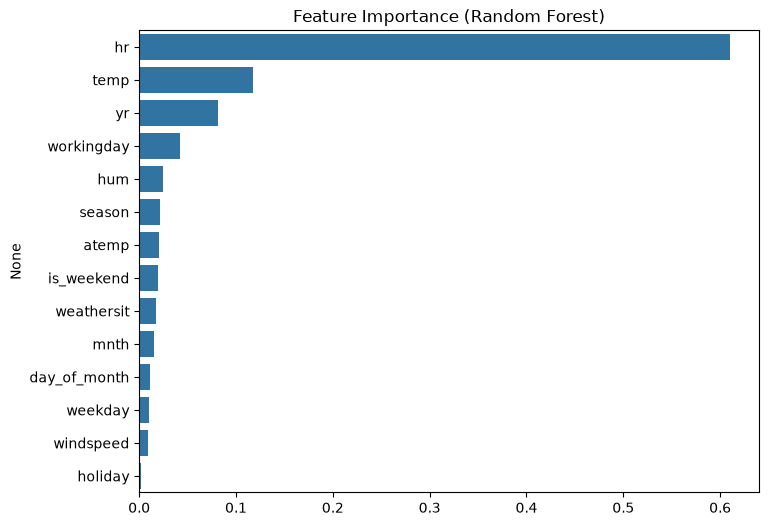

In [17]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance (Random Forest)")
plt.show()